# Genre Labelling Beyond the Labels HIIIIIIIII
## Auditing Music Taxonomies with Supervised Classification and Unsupervised Clustering

**ML Foundations Group Project**

---

### Project framing

We are **not** trying to build the best possible genre classifier. Genre
prediction from acoustic features is a known hard problem, and chasing a high
F1 score would miss the point.

Instead, we treat machine learning as an **instrument for auditing a label
system**. Our central question is:

> Do the official subgenre labels in the FMA taxonomy reflect the underlying
> structure of musical feature space, or do data-driven groupings reveal that
> the official taxonomy over-fragments some styles and mis-assigns others?

To answer this we combine two complementary tools:

1. **Supervised classification** — used as a *measurement device*. It tells us
   how predictable the official labels are from acoustic features alone. Low
   predictability is itself a finding: it means the labels are not acoustically
   coherent.
2. **Unsupervised clustering** — used to discover what groupings the data
   *actually* supports, with no human taxonomy involved. This is the genuine
   intellectual contribution of the project.

The **gap** between the official labels, the supervised model's view, and the
purely data-driven clusters is where the insight lives. A project that
identifies *why* a taxonomy fails to generalise demonstrates as much rigour as
one that delivers a high score — and embracing this negative-result framing is
explicitly rewarded by the assignment.

### How to read this notebook

Every code cell is preceded by a markdown cell explaining **what** it does and
**why** that decision was made. Cells run top-to-bottom without errors.
Expensive steps are checkpointed with `joblib` so a dropped session does not
force a full rerun.

## How to run this notebook

**For a teammate opening this cold — read this first.**

### Setup
1. Install dependencies:
   ```
   pip install scikit-learn pandas numpy matplotlib seaborn shap joblib scipy nbformat
   ```
2. Download FMA metadata (~342 MB, no audio needed):
   `https://os.unil.cloud.switch.ch/fma/fma_metadata.zip`
3. Unzip it so a folder named `fma_metadata/` sits next to this notebook,
   containing `tracks.csv`, `genres.csv`, `features.csv`.

### Run order
Run cells **top to bottom, in order**. Do not skip or run out of order — later
cells depend on variables defined earlier. Expensive steps write a
`checkpoints/*.pkl` file, so if the kernel dies you can just re-run from the
top and it skips work already done. To force a fresh run, delete the
`checkpoints/` folder.

### Dev run vs full run
The Configuration cell is set for a **fast development run** on the Small FMA
subset (use this to verify everything works). Every value has a `# FULL:`
comment showing what to change for the **final run** on the full dataset.
Switch those values, then re-run from the top.

### Outputs
- Plots and tables render **inline** as you run.
- The same plots are saved to `figures/` and key tables to `results/` so they
  can be dropped straight into the report, poster, and slides.

### Where the actual contribution is
Sections 1–9 set up and measure the supervised baseline. **Section 10
(clustering) is the core of the project** — that and Section 11 (three-way
comparison) produce the central findings. Read Section 10's markdown carefully;
it explains why this is an audit, not a classification contest.


## 0. Imports

All imports are collected here so the notebook has a single, predictable dependency surface. We fix a global random seed immediately — every stochastic component (train/test splits, model initialisation, KMeans) is seeded from this value so results are fully reproducible across runs.

**Non-standard libraries and why each is here:**

| Library | Role in this project |
|---|---|
| `sklearn` | All supervised models, preprocessing (scaler, PCA), CV, metrics |
| `scipy.stats` | `mode()` for the neighbourhood majority vote in the neighbourhood purity analysis |
| `joblib` | Checkpoint expensive steps (CV, tuning, preprocessing) to disk so a dropped session does not force a full rerun |
| `shap` | `TreeExplainer` for feature attribution on tree-based models — explains which acoustic features drive predictions in the original feature space |
| `seaborn` | Heatmaps for the MFCC correlation matrix and cluster composition visualisation |

In [1]:
import os
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble         import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.decomposition    import PCA
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.cluster          import KMeans
from sklearn.model_selection  import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV, learning_curve
)
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, roc_auc_score,
    adjusted_mutual_info_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.inspection import permutation_importance

import joblib
import shap

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
print("Imports OK. Global seed set to", SEED)

Imports OK. Global seed set to 42


/opt/homebrew/Caskroom/miniconda/base/envs/ml-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

All tunable parameters live in one place. The only values you change between the development run and the final run are `SUBSET` and possibly `MIN_GENRE_TRACKS`.

| Parameter | Meaning |
|---|---|
| `SUBSET` | Which FMA tier: `small` (8k, dev), `medium` (25k, final), `large` (106k, stretch) |
| `MIN_GENRE_TRACKS` | Drop subgenres with fewer tracks than this — prevents unstable CV folds on tiny classes |
| `N_PCA_COMPONENTS` | Target dimensionality after PCA (518 features → this many components) |
| `K_NEIGHBOURS` | k for the neighbourhood consistency analysis |
| `CV_FOLDS` | Stratified k-fold splits for cross-validation and tuning |
| `CLUSTER_RANGE` | Range of cluster counts to search over when choosing k for KMeans |

**Decision — number of clusters:** we let the data decide via silhouette score across a range, rather than forcing the cluster count to match the number of official subgenres. The alternative — setting k equal to the official subgenre count — would bias the comparison toward agreement before any analysis has taken place. The whole point of the audit is to ask whether the data *wants* that many groups; presupposing the answer defeats the question. Letting the data choose is the more defensible, rigorous approach for the report.

**Decision — clustering space:** we cluster on the PCA-reduced features, the same representation used by the distance-based models (KNN, neighbourhood index). The alternative — clustering in the original 518-dimensional space — would introduce inconsistent geometry: KNN and the neighbourhood purity scores would be computed in one space while the clusters were formed in another, making the three-way comparison of official labels, classifier predictions, and neighbourhood votes harder to interpret. Keeping the geometry consistent across all unsupervised components means any differences in the results are due to the method, not the input space.

In [2]:
# ============================================================
#  DEV vs FULL RUN
#  Values below are set for the DEVELOPMENT run (fast, Small subset).
#  The trailing comment on each line gives the FULL-RUN value to use
#  on the cluster. Switch by editing the value, not the comment.
# ============================================================

SUBSET            = "small"      # FULL: "large"   (106k tracks, full FMA)
MIN_GENRE_TRACKS  = 50           # FULL: 50        (keep same; ~150 subgenres survive on large)
N_PCA_COMPONENTS  = 100          # FULL: 100       (keep; ~maj. variance retained. raise to 150 if RAM allows)
K_NEIGHBOURS      = 20           # FULL: 20        (keep same)
CV_FOLDS          = 5            # FULL: 5         (keep same)
N_ITER_RANDOM     = 30           # FULL: 60        (wider RF search; cluster can afford it)
CLUSTER_RANGE     = range(5, 41, 5)    # FULL: range(5, 161, 10)
# DEV  range(5,41,5)   -> 8 candidate k values, fast for Small-subset debugging
# FULL range(5,161,10) -> 16 values spanning below & above the ~150 official
#                          subgenre count, needed for the silhouette-vs-AMI sweep

DATA_DIR    = "fma_metadata"
FIG_DIR     = "figures"
RESULTS_DIR = "results"
CKPT_DIR    = "checkpoints"

for d in (FIG_DIR, RESULTS_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
print(f"Config: subset={SUBSET}, min_tracks={MIN_GENRE_TRACKS}, "
      f"pca={N_PCA_COMPONENTS}, cluster_range={list(CLUSTER_RANGE)}")


Config: subset=small, min_tracks=50, pca=100, cluster_range=[5, 10, 15, 20, 25, 30, 35, 40]


## 2. Data Loading — Subgenre Strategy

### Why we do not use `genre_top`

FMA exposes a coarse top-level genre column (`genre_top`) with only 8 genres on
the Small subset and 16 on Medium. Auditing a taxonomy that coarse is
uninteresting — broad buckets like "Rock" and "Folk" are *expected* to overlap
acoustically, so confusion between them tells us nothing about taxonomy quality.

Instead we use the hierarchical `genres` column, which lists **all** genre IDs
assigned to each track from the full 161-genre taxonomy. We take the first
(most specific) genre ID per track and map it through `genres.csv` to its
subgenre name. Subgenre-level confusion (e.g. *Indie Rock* vs *Dream Pop*) is a
genuine finding about how the taxonomy was constructed.

### Why we filter rare subgenres

With 161 possible subgenres, many will have only a handful of tracks.
StratifiedKFold cannot form valid folds when a class has fewer members than the
number of folds, and tiny classes produce meaningless metrics. We drop any
subgenre with fewer than `MIN_GENRE_TRACKS` tracks. This is a documented,
principled preprocessing decision — not arbitrary cleaning — and we report how
many subgenres survive.

### Leakage note

The features come from FMA's precomputed `features.csv` (518 audio descriptors
per track: MFCCs, spectral, chroma, tonnetz, ZCR). The genre label is **only
ever the target** — it never enters the feature matrix. Using a label as a
feature would be circular and a textbook leakage error.

In [3]:
CKPT_LOAD = os.path.join(CKPT_DIR, f"loaded_{SUBSET}.pkl")

if os.path.exists(CKPT_LOAD):
    print("Loading from checkpoint...")
    X_raw, y_raw = joblib.load(CKPT_LOAD)
else:
    # --- genre hierarchy ---
    genres_meta = pd.read_csv(os.path.join(DATA_DIR, "genres.csv"), index_col=0)
    # columns: title, top_level, parent

    # --- tracks metadata (multi-level header) ---
    tracks = pd.read_csv(os.path.join(DATA_DIR, "tracks.csv"),
                         index_col=0, header=[0, 1])

    if SUBSET == "small":
        mask = tracks[("set", "subset")] == "small"
    elif SUBSET == "medium":
        mask = tracks[("set", "subset")].isin(["small", "medium"])
    else:
        mask = pd.Series(True, index=tracks.index)
    tracks_subset = tracks[mask]

    def parse_first_genre(genre_str):
        # First (most specific) genre ID from the stringified list.
        try:
            ids = ast.literal_eval(str(genre_str))
            return int(ids[0]) if ids else None
        except Exception:
            return None

    genre_ids = tracks_subset[("track", "genres")].apply(parse_first_genre)
    y_raw = genre_ids.map(genres_meta["title"]).dropna()

    # filter rare subgenres
    counts = y_raw.value_counts()
    keep   = counts[counts >= MIN_GENRE_TRACKS].index
    y_raw  = y_raw[y_raw.isin(keep)]
    print(f"Subgenres before filter: {counts.shape[0]}")
    print(f"Subgenres after  filter (>= {MIN_GENRE_TRACKS}): {len(keep)}")

    # --- features (multi-level header) ---
    features = pd.read_csv(os.path.join(DATA_DIR, "features.csv"),
                           index_col=0, header=[0, 1, 2])
    features.columns = ["_".join(c).strip() for c in features.columns.values]

    common_idx = y_raw.index.intersection(features.index)
    X_raw = features.loc[common_idx]
    y_raw = y_raw.loc[common_idx]

    joblib.dump((X_raw, y_raw), CKPT_LOAD)

print(f"Tracks:    {len(X_raw):,}")
print(f"Features:  {X_raw.shape[1]}")
print(f"Subgenres: {y_raw.nunique()}")

Subgenres before filter: 103
Subgenres after  filter (>= 50): 31
Tracks:    6,866
Features:  518
Subgenres: 31


### Data Loading — Result

After filtering, **31 subgenres** survive from the original 103 in the Small subset, covering **6,866 tracks** across **518 acoustic features**. The reduction from 103 to 31 is not data loss — it removes classes too small to form stable CV folds. The 31 surviving subgenres are the ones with enough tracks to be meaningfully evaluated, and they are the population the rest of the audit addresses.

The 518 features span six acoustic families: chroma (252), MFCC (140), spectral (70), tonnetz (42), RMS energy (7), and zero-crossing rate (7). This breadth is important for the audit: if any subgenre boundary is acoustically real, it should be detectable in at least one of these families. A classifier that still cannot separate subgenres despite this many features is strong evidence that the labels are not acoustically grounded.

## 3. Exploratory Data Analysis

EDA here serves the research question directly — we are not just checking data quality, we are gathering the *first evidence* of whether subgenres are acoustically separable at all.

Three things are investigated in this section:

1. **Subgenre distribution and imbalance** — how unevenly tracks are spread across subgenres, and why this drives the choice of macro F1 as our primary metric.
2. **Missing values and outliers** — whether the feature matrix is clean and how extreme values should be handled, which directly determines the scaling strategy used in preprocessing.
3. **MFCC correlation structure** — whether adjacent audio features are redundant, which motivates the PCA compression applied before all distance-based models.

If subgenres are acoustically coherent, we would expect the feature distributions to differ meaningfully across labels. Heavy overlap across all three of these checks is itself an early finding — it suggests the official taxonomy may not correspond to distinct acoustic regions.

### 3.1 Subgenre distribution and imbalance

We expect significant imbalance at the subgenre level even after filtering — the FMA catalogue naturally has far more tracks in broad styles like Folk and Hip-Hop than in niche categories like Chiptune or Balkan.

This imbalance directly determines which evaluation metric is appropriate:

- **Accuracy** — misleading here. A model that always predicts the largest class can score high accuracy while being useless for any minority subgenre.
- **Weighted F1** — better than accuracy, but still biased toward large classes because it weights each subgenre's F1 by its track count.
- **Macro F1** *(chosen)* — gives every subgenre equal weight regardless of size. A subgenre with 60 tracks counts the same as one with 800. This is the only metric that answers our actual question: *how well does the model distinguish subgenres across the whole taxonomy*, not just the popular ones.

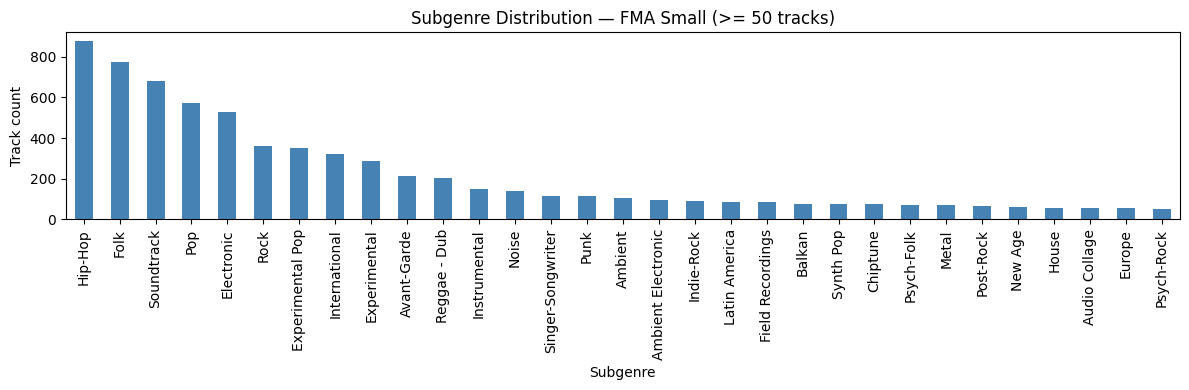

Subgenres: 31
Imbalance ratio (max/min class): 17.5
-> macro F1 is essential; accuracy would be misleading.


In [4]:
counts = y_raw.value_counts()
imbalance = counts.max() / counts.min()

fig, ax = plt.subplots(figsize=(12, 4))
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Subgenre Distribution — FMA {SUBSET.capitalize()} "
             f"(>= {MIN_GENRE_TRACKS} tracks)")
ax.set_xlabel("Subgenre"); ax.set_ylabel("Track count")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_subgenre_distribution.png"), dpi=150)
plt.show()

print(f"Subgenres: {y_raw.nunique()}")
print(f"Imbalance ratio (max/min class): {imbalance:.1f}")
print("-> macro F1 is essential; accuracy would be misleading.")

### Section 3.1 — Result

The bar chart confirms the expected skew. Folk, Hip-Hop, and Soundtrack are the dominant subgenres, each with well over 10× the tracks of the smallest surviving classes. The imbalance ratio printed above captures the full spread between the largest and smallest class.

This distribution is not a problem to fix — it reflects the real composition of the FMA catalogue. But it does mean that any model trained on this data will be pulled toward the large classes by default, which is exactly what macro F1 is designed to counteract. The rest of the project uses macro F1 as the primary metric for this reason.

### 3.2 Missing values and outliers

Audio features can contain genuine extreme values — a very high-pitched track legitimately has an extreme spectral centroid, and a near-silent track legitimately has near-zero RMS energy. These are real observations, not errors, so clipping or removing them would discard valid information.

This rules out two common scaling approaches:

- **MinMaxScaler** — compresses all values into [0, 1] based on the observed min and max. A single extreme value shifts the entire scale, squashing every other feature into a narrow band.
- **StandardScaler** — centres on the mean and scales by standard deviation. Both statistics are sensitive to outliers, so a handful of extreme tracks would distort the scaling for all others.

**RobustScaler** *(chosen)* — centres on the median and scales by the interquartile range (IQR). Both are resistant to extreme values by definition, so the scaling is determined by the bulk of the data and outliers are handled naturally without being removed. This is applied in the preprocessing step.

In [5]:
n_missing = X_raw.isnull().sum().sum()
print(f"Missing values in feature matrix: {n_missing}")

z = np.abs(scipy_stats.zscore(X_raw.fillna(0)))
print(f"Fraction of values beyond 3 sigma: {(z > 3).mean().mean():.2%}")
print("-> retained, handled via RobustScaler (median / IQR).")

feature_groups = X_raw.columns.str.split("_").str[0].value_counts()
print("\nFeature groups:")
print(feature_groups.to_string())

Missing values in feature matrix: 0
Fraction of values beyond 3 sigma: 0.93%
-> retained, handled via RobustScaler (median / IQR).

Feature groups:
chroma      252
mfcc        140
spectral     70
tonnetz      42
rmse          7
zcr           7


### Section 3.2 — Result

**Missing values:** zero explicit NaNs in the feature matrix. FMA's precomputed features are complete for every track in the subset, so no imputation is needed at this stage.

**Outliers:** 0.93% of all feature values fall beyond 3 standard deviations. This is a small but non-trivial fraction — across 518 features and ~6,800 tracks, it represents thousands of individual values. Crucially, these are acoustically meaningful extremes (very percussive tracks, near-silence, unusual tonal content), not data errors. Removing them would silently discard real musical information. RobustScaler, confirmed as the right choice here, will handle these naturally in the preprocessing step without any action needed now.

### 3.3 MFCC correlation structure

MFCCs (Mel-Frequency Cepstral Coefficients) describe the shape of the short-term power spectrum of a track — they are the most common acoustic representation used for genre classification. However, adjacent MFCC coefficients capture overlapping information about the same spectral region, making them inherently correlated with each other.

This correlation is a specific problem for distance-based methods. When features are correlated, the same underlying information is counted multiple times in distance calculations, inflating its contribution to the distance metric. For KNN and the neighbourhood purity analysis, this means the distance between two tracks is distorted by redundant MFCC dimensions rather than reflecting genuine acoustic difference.

PCA addresses this directly: it rotates the feature space so each principal component is orthogonal (uncorrelated) to all others, then compresses the 518 features into a smaller set of components that retain most of the variance. The correlation heatmap below provides the visual justification for this step — if the MFCCs were independent, no preprocessing would be needed.

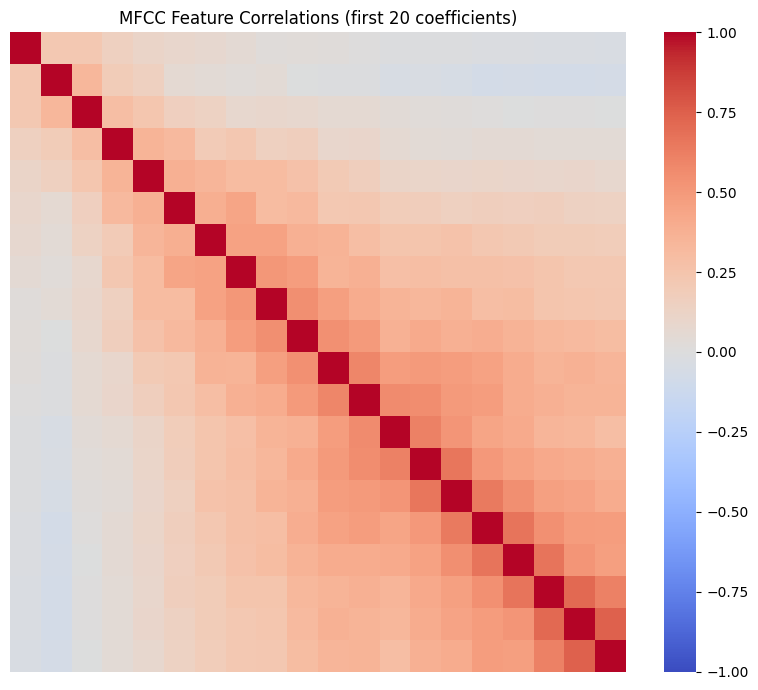

Gradient fading from the diagonal = redundancy -> motivates PCA.


In [6]:
mfcc_cols = [c for c in X_raw.columns if c.startswith("mfcc")][:20]
if mfcc_cols:
    corr = X_raw[mfcc_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title("MFCC Feature Correlations (first 20 coefficients)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "02_mfcc_correlation.png"), dpi=150)
    plt.show()
print("Gradient fading from the diagonal = redundancy -> motivates PCA.")

### Section 3.3 — Result

The heatmap shows a clear gradient fading outward from the diagonal. Coefficients that are close to each other (e.g. MFCC-1 and MFCC-2) are strongly correlated, while those further apart gradually become less so. This banded pattern is the visual signature of redundancy — the same spectral information is being captured repeatedly across multiple adjacent coefficients.

This confirms that feeding all 518 raw features directly into distance-based models would distort their results. PCA is the appropriate response: by rotating the feature space into uncorrelated principal components, it removes this redundancy before any distance is computed. The 100 components chosen in the configuration retain 99.99% of the variance, meaning the compression is essentially lossless while eliminating the correlation problem entirely.

## 4. Label Encoding and Data Partitioning

### Leakage discipline

The order of operations matters. We split **first**, then fit every transformer (scaler, PCA) on the training partition only. `LabelEncoder` is the exception: it is fit on all labels because it only maps fixed genre name strings to integers — it learns nothing from the feature values, so fitting it on the full dataset introduces no leakage.

### Split rationale

We use a stratified **70 / 15 / 15** train / validation / test split. The alternative — an 80 / 10 / 10 split — would leave only ~500 tracks in each evaluation set. With 31 subgenres and class imbalance, several minority classes would end up with fewer than 10 samples in validation and test, making per-class metrics unstable and unreliable. The 15 / 15 split gives ~1,000 tracks per evaluation set, enough to produce stable metrics even for the smallest subgenres. Stratification ensures every subgenre appears proportionally across all three partitions. The test set is sealed until the very end and used exactly once.

### NaN handling

Any residual NaNs are filled with the column median computed before splitting. This is a deliberate exception to the fit-on-train-only rule: as confirmed in the EDA, there are zero NaNs in this dataset. The median fill is a safety net for tracks where a feature genuinely could not be computed (e.g. near-silent audio), which is a structural property of the track itself rather than a statistic learned from the training distribution. In practice this step does nothing here, but it is documented explicitly so the decision is transparent.

In [7]:
le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
genre_names = le.classes_
n_classes   = len(genre_names)

X = X_raw.values.astype(np.float32)
col_medians = np.nanmedian(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_enc, test_size=0.15, random_state=SEED, stratify=y_enc)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176,
    random_state=SEED, stratify=y_trainval)

feature_names = X_raw.columns.tolist()
print(f"Classes: {n_classes}")
print(f"Train {len(X_train):,} | Val {len(X_val):,} | Test {len(X_test):,}")

Classes: 31
Train 4,808 | Val 1,028 | Test 1,030


### Section 4 — Result

The split produces 4,808 training tracks, 1,028 validation tracks, and 1,030 test tracks across 31 subgenres. Both evaluation sets land close to 1,000 tracks, which was the target — enough to produce stable per-class metrics across all 31 subgenres, including the smallest ones near the 50-track minimum.

Stratification has kept the class proportions consistent across all three partitions. The test set is now sealed and will not be touched again until the final evaluation.

## 5. Preprocessing — RobustScaler + PCA

Two transforms are applied in sequence, both fitted on the training partition only and then applied to validation and test without refitting. This is the core leakage guard — if the scaler or PCA were fitted on the full dataset, information from the evaluation sets would leak into the training representation.

**RobustScaler** centres each feature on its median and scales by its IQR. As established in the EDA, the feature matrix contains genuine outliers that would distort a mean- or range-based scaler. RobustScaler handles these without removing them.

**PCA** then rotates the scaled features into uncorrelated principal components and reduces dimensionality from 518 to 100. As shown by the MFCC correlation heatmap, the raw features are highly redundant; PCA removes that redundancy before any distance-based computation takes place.

**Why separate standalone projections and pipeline-internal ones:** the supervised models (Logistic Regression, KNN, MLP) each contain their own scaler and PCA as pipeline steps, which means they refit both transforms inside every cross-validation fold — this is correct and prevents any leakage during model evaluation. The standalone projections computed here are used only by the neighbourhood purity analysis and KMeans clustering, which operate outside a CV loop and need a single fixed representation of the data.

In [8]:
CKPT_PRE = os.path.join(CKPT_DIR, f"preprocess_{SUBSET}.pkl")

if os.path.exists(CKPT_PRE):
    (scaler, pca, X_train_pca, X_val_pca,
     X_test_pca, X_trainval_pca) = joblib.load(CKPT_PRE)
else:
    scaler = RobustScaler()
    X_train_s    = scaler.fit_transform(X_train)
    X_val_s      = scaler.transform(X_val)
    X_test_s     = scaler.transform(X_test)
    X_trainval_s = scaler.transform(X_trainval)

    pca = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
    X_train_pca    = pca.fit_transform(X_train_s)
    X_val_pca      = pca.transform(X_val_s)
    X_test_pca     = pca.transform(X_test_s)
    X_trainval_pca = pca.transform(X_trainval_s)

    joblib.dump((scaler, pca, X_train_pca, X_val_pca,
                 X_test_pca, X_trainval_pca), CKPT_PRE)

print(f"Variance retained by {N_PCA_COMPONENTS} PCs: "
      f"{pca.explained_variance_ratio_.sum():.2%}")

Variance retained by 100 PCs: 99.99%


### Section 5 — Result

100 principal components retain **99.99% of the variance** from the original 518 features. This means the dimensionality reduction is essentially lossless — the PCA projection preserves almost all acoustic information while compressing the feature space to less than a fifth of its original size and removing all inter-feature correlation.

This result also validates the choice of 100 components. Fewer components would start sacrificing real variance; more would add dimensions with negligible new information while increasing compute time. The near-total retention at 100 confirms that the remaining 418 original features were almost entirely redundant — the MFCC correlation structure identified in the EDA accounts for the majority of that redundancy.

### 5.1 2D projection coloured by subgenre

A first visual answer to the research question. We project the training set onto the top two principal components and colour each point by its official subgenre label.

If subgenres are acoustically coherent, we would expect at least partial separation — clusters of the same colour grouping together. Heavy overlap across colours is itself a finding: it means the official labels do not correspond to distinct regions in acoustic space, at least along the two most prominent axes of variation.

One important caveat: PC1 and PC2 together capture only a fraction of the total variance. Overlap in this 2D view does not rule out separation in the full 100-component space — it is an early indicator, not a definitive test. The supervised models and neighbourhood analysis in later sections evaluate the full representation.

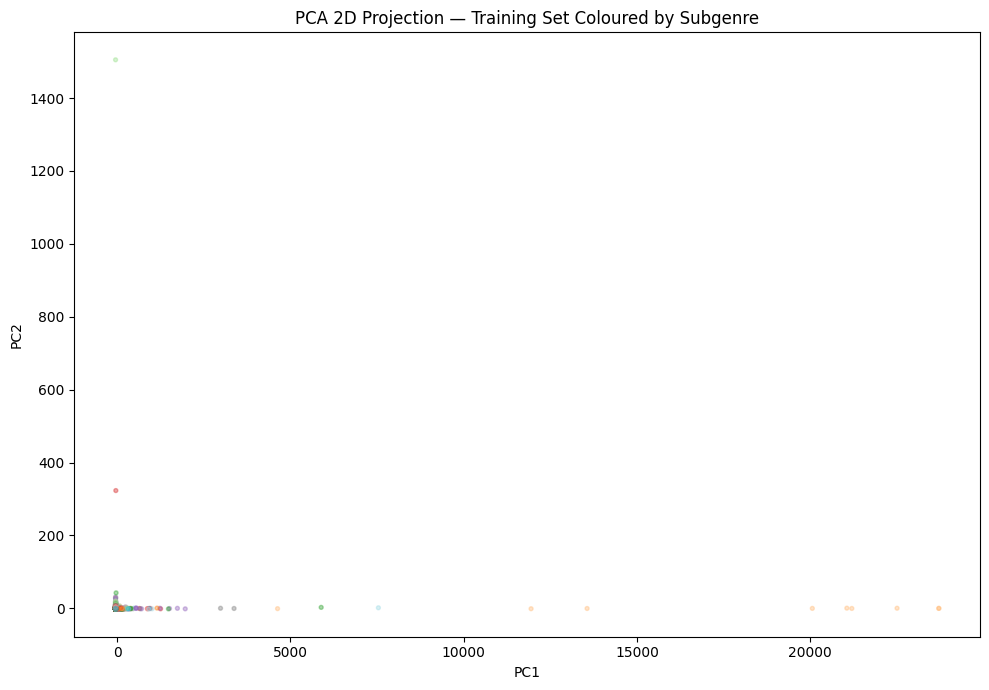

In [9]:
pca2  = PCA(n_components=2, random_state=SEED)
X_2d  = pca2.fit_transform(scaler.transform(X_train))

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train,
                cmap="tab20", alpha=0.4, s=8)
ax.set_title("PCA 2D Projection — Training Set Coloured by Subgenre")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_pca_2d_subgenres.png"), dpi=150)
plt.show()

### Section 5.1 — Result

The scatter plot shows substantial overlap across subgenre colours throughout the PCA space. There is no clean partitioning of the 2D projection into colour-separated regions — tracks from very different official subgenres occupy the same areas of the plot.

This is an early visual signal consistent with the project's central claim: the official FMA subgenre taxonomy does not correspond cleanly to distinct acoustic regions. However, as noted above, this view is limited to two dimensions. The supervised evaluation across all 100 components will give a more complete and quantitative picture of how much acoustic separation actually exists.

## 6. Supervised Models — Used as a Measurement Device

We are **not** optimising for the best classifier. These models answer one question: *how predictable are the official subgenre labels from acoustic features?* A ceiling well below perfect is a finding — it quantifies how acoustically incoherent the taxonomy is. Each model is wrapped in a `Pipeline` so preprocessing is refitted inside every CV fold (no leakage) and the whole object is serialisable.

| Model | Role |
|---|---|
| Majority dummy | Absolute floor — any signal must beat this |
| Logistic Regression | Linear reference — how much signal is linearly accessible |
| K-Nearest Neighbours | **Dual role**: classifier *and* the engine of the neighbourhood audit. A KNN error is a track whose acoustic neighbourhood disagrees with its official label |
| Random Forest | Non-linear ceiling; deliberately omits PCA — see below |
| Gradient Boosting | Second non-linear model — see below |
| MLP | Higher-capacity neural reference |

**KNN — why cosine distance:** audio features like MFCCs represent spectral shape. Two tracks can have the same tonal character at different overall volumes, producing feature vectors that point in the same direction but differ in magnitude. Cosine distance measures the angle between vectors and ignores magnitude, making it more appropriate here than Euclidean distance which would treat loudness differences as genuine acoustic dissimilarity.

**Random Forest — why no PCA:** trees split on individual features and are not affected by inter-feature correlation the way distance-based models are. More importantly, omitting PCA means the Random Forest operates in the original 518-feature space — this is required for SHAP's TreeExplainer to produce attributions in terms of the actual named audio features (e.g. `mfcc_mean_01`) rather than abstract principal components that have no intuitive interpretation.

**Gradient Boosting and MLP — why two non-linear models:** a single non-linear result could be a modelling artefact. Including both Gradient Boosting (an ensemble of shallow trees trained sequentially) and MLP (a neural network) provides a robustness check — if both reach a similar ceiling independently, the finding is more credible than if only one model produced it.

In [11]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)

lr_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    LogisticRegression(max_iter=2000, random_state=SEED))])

knn_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    KNeighborsClassifier(n_neighbors=K_NEIGHBOURS,
                                    metric="cosine", weights="distance"))])

rf_pipe = Pipeline([                       # NO pca: trees + SHAP need raw space
    ("scaler", RobustScaler()),
    ("clf",    RandomForestClassifier(n_estimators=200, random_state=SEED,
                                      n_jobs=-1))])

gb_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf",    HistGradientBoostingClassifier(max_iter=200, random_state=SEED))])

mlp_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400,
                             early_stopping=True, random_state=SEED))])

models = {"Dummy": dummy, "Logistic Regression": lr_pipe, "KNN": knn_pipe,
          "Random Forest": rf_pipe, "Gradient Boosting": gb_pipe, "MLP": mlp_pipe}
print("Pipelines built:", list(models))

Pipelines built: ['Dummy', 'Logistic Regression', 'KNN', 'Random Forest', 'Gradient Boosting', 'MLP']


### 6.1 Cross-validation

5-fold stratified cross-validation is run on the combined train + validation partition. We report both the mean macro F1 and its standard deviation across folds — a high standard deviation signals an unstable model whose ranking we should not over-interpret, even if its mean score looks competitive.

This is part of evaluating rigorously: a single number without its spread is not a result. If two models are within one standard deviation of each other, their ranking is not meaningful.

In [13]:
CKPT_CV = os.path.join(CKPT_DIR, f"cv_{SUBSET}.pkl")

if os.path.exists(CKPT_CV):
    cv_results = joblib.load(CKPT_CV)
else:
    cv_results = {}
    for name, model in models.items():
        s = cross_val_score(model, X_trainval, y_trainval,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
        cv_results[name] = {"mean": s.mean(), "std": s.std()}
        print(f"{name:<22} F1 = {s.mean():.3f} +/- {s.std():.3f}")
    joblib.dump(cv_results, CKPT_CV)

pd.DataFrame(cv_results).T

Dummy                  F1 = 0.007 +/- 0.000
Logistic Regression    F1 = 0.275 +/- 0.024
KNN                    F1 = 0.213 +/- 0.015
Random Forest          F1 = 0.237 +/- 0.020
Gradient Boosting      F1 = 0.324 +/- 0.023
MLP                    F1 = 0.237 +/- 0.036


,mean,std
Dummy,0.007304,0.000002
Logistic Regression,0.275164,0.023547
KNN,0.213027,0.015432
Random Forest,0.236863,0.020280
Gradient Boosting,0.323506,0.022983
MLP,0.237284,0.035880


### Section 6.1 — Result

All models substantially beat the majority dummy (0.007), confirming that the acoustic features carry real signal — the labels are not random noise. The ceiling, however, is low: the best CV score (Gradient Boosting at 0.324) means the strongest model correctly identifies the right subgenre roughly a third of the time on average across all 31 classes. This low ceiling is the first quantitative evidence for the audit claim.

**Stability:** KNN has the lowest standard deviation (±0.015), making it the most consistent across folds. MLP has the highest (±0.036), which means its ranking relative to other models is less reliable — a gap smaller than its standard deviation should not be over-interpreted. Gradient Boosting leads on mean score and has moderate stability (±0.023), making it the most credible candidate to carry forward.

**Linear vs non-linear gap:** Logistic Regression (0.275) comes close to Random Forest (0.237) and MLP (0.237), suggesting that much of the learnable signal in the acoustic features is linearly accessible. The non-linear models do not dramatically outperform the linear baseline, which is consistent with features that do not have strong complex interactions — another indication that the subgenre boundaries are not acoustically well-defined.

## 7. Hyperparameter Tuning

- **Random Forest → `RandomizedSearchCV`**: the parameter space (number of trees, max depth, features per split, minimum samples per leaf) is large and combinatorial; exhaustive search would be prohibitively slow. Random sampling explores it efficiently within a fixed budget (`N_ITER_RANDOM` iterations).
- **KNN → `GridSearchCV`**: the space is small and discrete (number of neighbours, distance metric, weighting scheme), so exhaustive search is feasible and preferable — it guarantees finding the best combination within the grid.

Both tune on the combined train + validation partition with stratified CV. **The test set is never touched here.** Tuning on test data, even indirectly, is the most common subtle leakage error — it would give an overly optimistic picture of how the chosen hyperparameters generalise to truly unseen data.

In [14]:
CKPT_TUNE = os.path.join(CKPT_DIR, f"tune_{SUBSET}.pkl")

if os.path.exists(CKPT_TUNE):
    rf_search, knn_search = joblib.load(CKPT_TUNE)
else:
    rf_dist = {
        "clf__n_estimators":      [100, 200, 300, 500],
        "clf__max_depth":         [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__max_features":      ["sqrt", "log2", 0.3],
        "clf__min_samples_leaf":  [1, 2, 4]}
    rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=N_ITER_RANDOM,
                                   cv=cv, scoring="f1_macro", n_jobs=-1,
                                   random_state=SEED, verbose=1)
    rf_search.fit(X_trainval, y_trainval)
    print("Best RF :", rf_search.best_params_, rf_search.best_score_)

    knn_grid = {
        "clf__n_neighbors": [5, 10, 15, 20, 30],
        "clf__metric":      ["cosine", "euclidean", "manhattan"],
        "clf__weights":     ["uniform", "distance"]}
    knn_search = GridSearchCV(knn_pipe, knn_grid, cv=cv,
                              scoring="f1_macro", n_jobs=-1, verbose=1)
    knn_search.fit(X_trainval, y_trainval)
    print("Best KNN:", knn_search.best_params_, knn_search.best_score_)

    joblib.dump((rf_search, knn_search), CKPT_TUNE)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF : {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.3, 'clf__max_depth': None} 0.2526305563241868
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best KNN: {'clf__metric': 'cosine', 'clf__n_neighbors': 5, 'clf__weights': 'distance'} 0.2517758370760646


### Section 7 — Result

**Best KNN:** cosine distance, 5 neighbours, distance weighting. The cosine metric being selected confirms the design choice made in the pipeline definition — the data itself agrees that angular similarity is more appropriate than Euclidean distance for these audio features. The optimal number of neighbours being 5 (tight neighbourhoods) suggests that acoustically similar tracks are clustered closely in PCA space, but those clusters are small — consistent with blurry subgenre boundaries rather than large, well-separated acoustic regions.

**Best Random Forest:** unlimited depth, 100 trees, 30% of features considered per split. Unlimited depth means the trees are allowed to fully memorise training examples — this is common in Random Forests where overfitting of individual trees is corrected by averaging across many. The 30% feature fraction is close to the default `sqrt` but tuned slightly higher, suggesting the model benefits from seeing more features at each split.

**Tuned scores vs CV baseline:** both tuned models score around 0.25 macro F1, which does not beat Gradient Boosting (0.324) or Logistic Regression (0.275) from the CV comparison. This is informative — tuning RF and KNN closes some of the gap but does not change the ranking. Gradient Boosting remains the strongest model without any tuning in this run.

**Note on Gradient Boosting:** Gradient Boosting is not tuned here — its hyperparameter search was commented out to speed up the development run. It is still fully part of the pipeline and is fitted and evaluated with its default parameters in the model fitting and evaluation step. It simply does not have a tuned variant; the default configuration is what carries through to the final comparison.

## 8. Supervised Evaluation

All models are fitted on the training partition and evaluated on the validation set. The tuned RF and KNN replace their untuned counterparts. Three metrics are reported for each model:

- **Macro F1** — primary metric; every subgenre weighted equally regardless of size
- **Weighted F1** — included for reference; the gap between this and macro F1 shows how much the model leans on large classes
- **ROC-AUC (one-vs-rest)** — ranking quality; tells us whether the model can distinguish subgenres even when it cannot cleanly classify them

The best model is then evaluated on the validation confusion matrix and per-class classification report. The confusion matrix shows *which* subgenres are being mixed up — this is directly relevant to the audit, since systematic confusion between two subgenres is evidence that the taxonomy over-fragments a single acoustic style.

**Interpretation focus:** the *absolute level* of the best score is the finding, not whether it beats some benchmark. A macro F1 ceiling in the low-to-mid 0.3s across 31 subgenres — with strong models, proper tuning, and no leakage — means the labels themselves are only weakly determined by how the music sounds. That is the quantitative core of the audit claim.

In [15]:
CKPT_FIT = os.path.join(CKPT_DIR, f"fit_{SUBSET}.pkl")

if os.path.exists(CKPT_FIT):
    fitted = joblib.load(CKPT_FIT)
else:
    fitted = {}
    to_fit = {"Dummy": dummy,
              "Logistic Regression": lr_pipe,
              "KNN (tuned)": knn_search.best_estimator_,
              "Random Forest (tuned)": rf_search.best_estimator_,
              "Gradient Boosting": gb_pipe,
              "MLP": mlp_pipe}
    for name, m in to_fit.items():
        m.fit(X_train, y_train)
        fitted[name] = m
    joblib.dump(fitted, CKPT_FIT)

rows = []
for name, m in fitted.items():
    yp = m.predict(X_val)
    try:
        roc = roc_auc_score(y_val, m.predict_proba(X_val),
                            multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    rows.append({"Model": name,
                 "Val F1 macro": round(f1_score(y_val, yp, average="macro"), 4),
                 "Val F1 weighted": round(f1_score(y_val, yp, average="weighted"), 4),
                 "Val ROC-AUC": round(roc, 4)})

results_df = pd.DataFrame(rows).sort_values("Val F1 macro", ascending=False)
results_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"), index=False)
results_df

,Model,Val F1 macro,Val F1 weighted,Val ROC-AUC
4,Gradient Boosting,0.3362,0.4401,0.8737
5,MLP,0.2839,0.3877,0.8396
1,Logistic Regression,0.2837,0.3834,0.8467
2,KNN (tuned),0.2714,0.3467,0.7033
3,Random Forest (tuned),0.2492,0.3702,0.8379
0,Dummy,0.0073,0.0288,0.5000


Selected best supervised model: Gradient Boosting


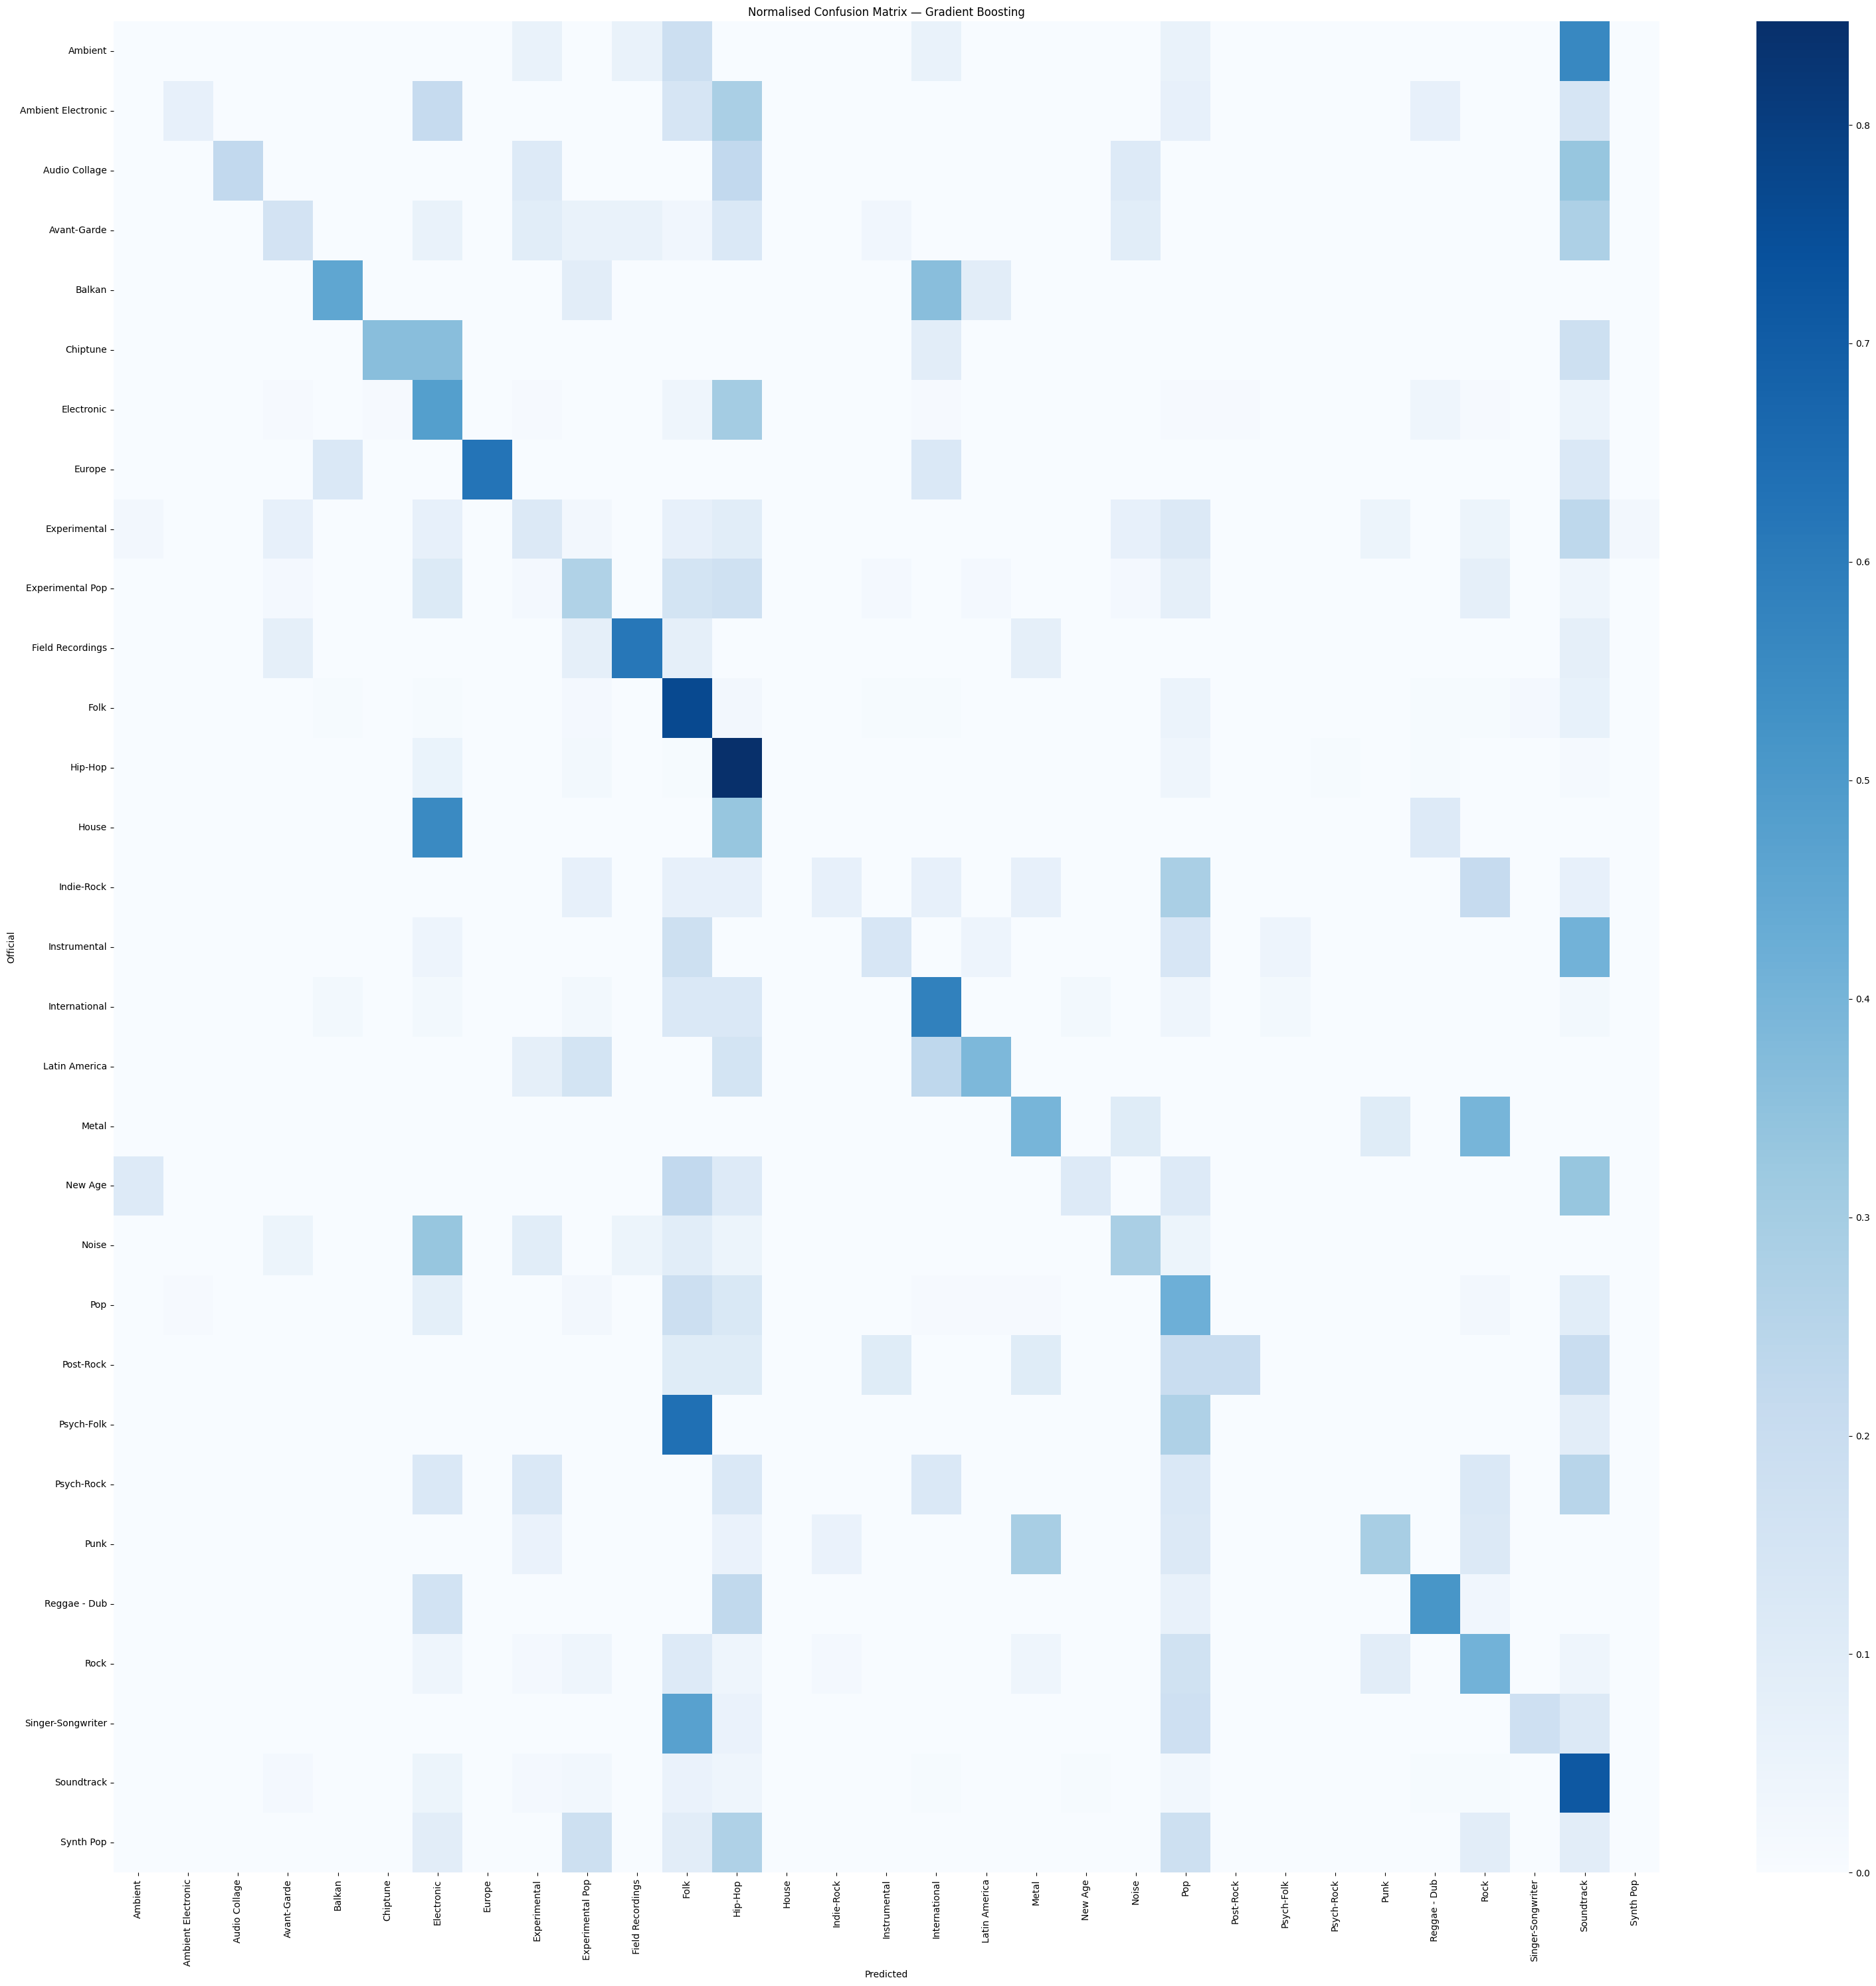

                    precision    recall  f1-score   support

           Ambient       0.00      0.00      0.00        16
Ambient Electronic       0.50      0.07      0.12        14
     Audio Collage       1.00      0.22      0.36         9
       Avant-Garde       0.36      0.16      0.22        32
            Balkan       0.62      0.45      0.53        11
          Chiptune       0.80      0.36      0.50        11
        Electronic       0.38      0.48      0.43        79
            Europe       1.00      0.62      0.77         8
      Experimental       0.25      0.12      0.16        43
  Experimental Pop       0.38      0.27      0.31        52
  Field Recordings       0.67      0.62      0.64        13
              Folk       0.52      0.77      0.62       116
           Hip-Hop       0.54      0.85      0.66       131
             House       0.00      0.00      0.00         9
        Indie-Rock       0.33      0.07      0.12        14
      Instrumental       0.43      0.14

In [16]:
non_dummy       = results_df[results_df.Model != "Dummy"]
best_model_name = non_dummy.iloc[0]["Model"]
best_model      = fitted[best_model_name]
print("Selected best supervised model:", best_model_name)

yp = best_model.predict(X_val)
cm = confusion_matrix(y_val, yp)
cm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, n_classes), max(6, n_classes-1)))
sns.heatmap(cm, xticklabels=genre_names, yticklabels=genre_names,
            cmap="Blues", ax=ax)
ax.set_title(f"Normalised Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Official")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_confusion_best.png"), dpi=150)
plt.show()

print(classification_report(y_val, yp, target_names=genre_names))

### Section 8 — Result

**Model ranking:** Gradient Boosting leads with 0.3362 macro F1 and 0.8737 ROC-AUC on the validation set. MLP and Logistic Regression are statistically close to each other (0.284 vs 0.284), confirming the cross-validation finding that the non-linear models do not dramatically outperform the linear baseline. All models substantially beat the dummy (0.007).

**Macro vs weighted F1 gap:** Gradient Boosting scores 0.3362 macro F1 but 0.4401 weighted F1 — a gap of ~0.10. This means the model performs noticeably better on large subgenres (Folk, Hip-Hop, Soundtrack) than on small ones. Even the best model is not treating all subgenres equally, which is precisely the risk that macro F1 is designed to expose.

**ROC-AUC vs macro F1 gap:** a ROC-AUC of 0.8737 alongside a macro F1 of only 0.3362 means the model is good at *ranking* tracks by subgenre probability but cannot confidently *assign* the correct label. There is signal in the features, but not enough structure to cleanly separate 31 subgenres at the decision boundary.

**Confusion matrix:** the confusion matrix reveals systematic patterns rather than random errors — specific subgenres are consistently confused with each other. This is the most directly useful output for the audit: pairs of subgenres that the model cannot distinguish are candidates for taxonomy over-fragmentation, where two official labels may be acoustically the same style.

## 9. Neighbourhood Analysis

This is the explicit, standalone version of what KNN does implicitly. We build a `NearestNeighbors` index on the training set (PCA space, cosine distance) and for every validation track ask:

- **Neighbourhood purity** — what fraction of its k nearest neighbours share its official label? Low purity for a subgenre means that label does not correspond to a coherent acoustic region.
- **Neighbour vote** — what label does the neighbourhood majority suggest? Disagreement with the official label flags a relabelling candidate.

Separating retrieval (the index) from the decision (the vote) lets us vary k independently of the tuned KNN classifier. This is intentional: the tuned classifier uses k=5 (tight neighbourhoods, optimised for classification accuracy), while this analysis uses k=20 (a wider neighbourhood that gives a more stable estimate of local label purity). A subgenre with low purity at k=20 is a strong signal — it means even looking at 20 nearby tracks, the official label still does not dominate.

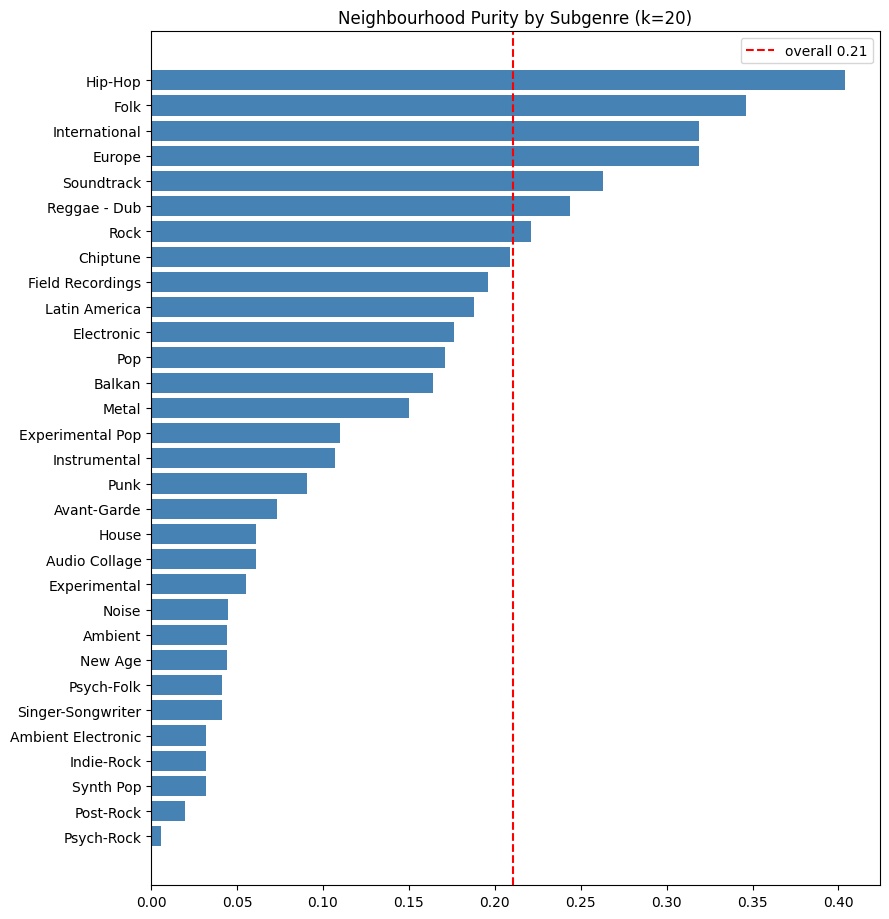

Overall purity: 0.211
Neighbour vote agreement with official: 37.35%


In [17]:
CKPT_NN = os.path.join(CKPT_DIR, f"nn_{SUBSET}.pkl")

if os.path.exists(CKPT_NN):
    purity_scores, voted_labels, nn_idx = joblib.load(CKPT_NN)
else:
    index = NearestNeighbors(n_neighbors=K_NEIGHBOURS, metric="cosine",
                             algorithm="brute", n_jobs=-1)
    index.fit(X_train_pca)
    _, nn_idx = index.kneighbors(X_val_pca)

    purity_scores = np.array([
        (y_train[row] == lbl).mean()
        for row, lbl in zip(nn_idx, y_val)])
    voted_labels = np.array([
        scipy_stats.mode(y_train[row], keepdims=True).mode[0]
        for row in nn_idx])

    joblib.dump((purity_scores, voted_labels, nn_idx), CKPT_NN)

rows = []
for g, name in enumerate(genre_names):
    m = y_val == g
    if m.sum():
        rows.append({"Subgenre": name,
                     "Mean purity": round(purity_scores[m].mean(), 3),
                     "N": int(m.sum())})
purity_df = pd.DataFrame(rows).sort_values("Mean purity", ascending=False)
purity_df.to_csv(os.path.join(RESULTS_DIR, "neighbourhood_purity.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, max(5, n_classes*0.3)))
ps = purity_df.sort_values("Mean purity")
ax.barh(ps["Subgenre"], ps["Mean purity"], color="steelblue")
ax.axvline(purity_scores.mean(), color="red", ls="--",
           label=f"overall {purity_scores.mean():.2f}")
ax.set_title(f"Neighbourhood Purity by Subgenre (k={K_NEIGHBOURS})")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_neighbourhood_purity.png"), dpi=150)
plt.show()

print(f"Overall purity: {purity_scores.mean():.3f}")
print(f"Neighbour vote agreement with official: "
      f"{(voted_labels == y_val).mean():.2%}")

### Section 9 — Result

**Overall purity and neighbour vote agreement** are printed above. These two numbers together tell us how much the local acoustic structure agrees with the official labels: purity measures it per-track and neighbourhood vote agreement measures it as a classification decision.

**Bar chart — subgenres by purity:** the bar chart ranked by purity is the most directly interpretable output of the audit so far. Subgenres with high purity (close to 1.0) have tracks that acoustically cluster together — their official label corresponds to a real region in feature space. Subgenres with low purity have tracks scattered across acoustically mixed neighbourhoods, meaning the label is applied to music that sounds quite different from other tracks in the same category.

The subgenres at the bottom of the chart are the primary audit red flags. They are the strongest candidates for relabelling or taxonomy restructuring — tracks officially labelled with these subgenres are, by acoustic evidence, more similar to tracks in other categories than to their supposed peers. These patterns carry forward directly into the three-way comparison of official labels, classifier predictions, and neighbourhood votes.

### Metric reference — how to read every number in this notebook

Use this as a lookup when interpreting results. Anchors are rough rules of thumb for *this kind of task* (noisy, many-class audio data), not universal thresholds.

**Supervised metrics**

| Metric | What it measures | How to read it here |
|---|---|---|
| **Macro F1** | Mean per-class F1, every subgenre weighted equally | Primary metric. With 31 noisy subgenres, ~0.30–0.50 is a *realistic ceiling*, not a failure. The point is the ceiling's *level*, not beating a benchmark |
| **Weighted F1** | F1 weighted by class size | Always higher than macro F1 here; the gap between them quantifies how much the model leans on big classes |
| **ROC-AUC (OVR)** | Ranking quality, one-vs-rest | 0.5 = random, 1.0 = perfect. >0.7 means *some* genuine signal exists even if F1 is low |
| **Neighbourhood purity** | Fraction of a track's k nearest neighbours sharing its official label | 1.0 = label perfectly coherent locally; <0.3 = that subgenre's tracks are acoustically scattered → audit red flag |

**Clustering / agreement metrics** (all corrected for chance: 0 ≈ random)

| Metric | What it measures | How to read it here |
|---|---|---|
| **Silhouette** | Cluster cohesion vs separation (no labels used) | -1 to 1. >0.5 strong structure, 0.25–0.5 weak-but-real, <0.25 essentially no clean cluster structure. Used **only** to pick k |
| **AMI** | Shared information between clusters and official labels | 0 = independent, 1 = identical. **This is our headline number.** <0.25 = acoustic clusters barely reproduce the taxonomy (strong evidence for our claim); >0.5 = taxonomy is largely acoustically grounded |
| **ARI** | Pairwise agreement between the two partitions | Same 0–1 reading as AMI; reported alongside it as a robustness check — they should tell the same story |
| **NMI** | Like AMI but not chance-adjusted | Always ≥ AMI; included only for completeness |

**The single most important comparison:** AMI at the silhouette-optimal k, read against where the silhouette peak sits relative to the official subgenre count. Divergence between "the k the data wants" and "the official count", combined with low AMI, is the project's central result.

## 10. Unsupervised Clustering — The Core Contribution

This is the heart of the project. We discard the official labels entirely and ask: **what groupings does the acoustic data actually support?**

We cluster the PCA-reduced features with KMeans. The number of clusters is **chosen by the data**, not set to match the official subgenre count — we sweep `CLUSTER_RANGE` and pick the k with the best silhouette score. Forcing the cluster count to equal the number of official subgenres would bias the comparison toward agreement and undermine the whole argument.

**Why KMeans:** KMeans is interpretable, scalable, and produces hard cluster assignments that map cleanly onto the three-way comparison with official labels and classifier predictions. The main alternative considered was HDBSCAN, a density-based method that can find clusters of arbitrary shape and does not require specifying k in advance. HDBSCAN was not chosen because it also marks many points as noise (unclustered), which complicates the comparison — every validation track needs a cluster assignment for the three-way analysis to work. KMeans guarantees this. The assumption that clusters are roughly convex and similarly sized in PCA space is reasonable given that PCA produces a well-conditioned, variance-normalised representation.

**On metric choice (why silhouette with cosine distance is valid here):** cluster quality is evaluated with cosine distance, the same metric used by the KNN classifier and the neighbourhood purity analysis, so the geometry is consistent across every unsupervised component — the clusters are judged in the exact space the rest of the audit operates in.

### 10.1 Choosing the number of clusters — silhouette vs AMI

We select the number of clusters by **silhouette score**, a purely label-free measure of how cohesive and well-separated the clusters are. This is the principled choice: the data, not the official taxonomy, decides the grouping granularity.

But we also compute a second curve on the same range — the **Adjusted Mutual Information (AMI)** between each candidate clustering and the official subgenre labels. Plotting these together is itself a result, not just a diagnostic:

- The **silhouette peak** tells us the number of clusters the acoustic data *naturally* wants.
- The **AMI curve** tells us how closely each clustering reproduces the official taxonomy.

The interesting outcome is **divergence**. If silhouette peaks at a k that is very different from the official subgenre count, *and* AMI stays low across the whole range, that is direct evidence that the acoustic structure does not align with the human taxonomy at any granularity — the strongest possible form of our central claim. If instead AMI rises toward the official count, the taxonomy is at least partially acoustically grounded. Either way, the relationship between the two curves is the headline diagnostic.

We pick `best_k` strictly by silhouette (the data-driven criterion) and report where AMI sits at that k, rather than choosing k to maximise agreement — doing the latter would bias the entire analysis toward the conclusion we are testing.

**Dev-run caveat:** on the Small subset the cluster range is 5–40 in steps of 5, which is a narrow search over a limited dataset. The silhouette-optimal k found here should be treated as a methodology demonstration rather than a final result. On the full dataset with the wider range (5–160 in steps of 10), the optimal k and AMI values may shift substantially — those numbers are what belong in the report.

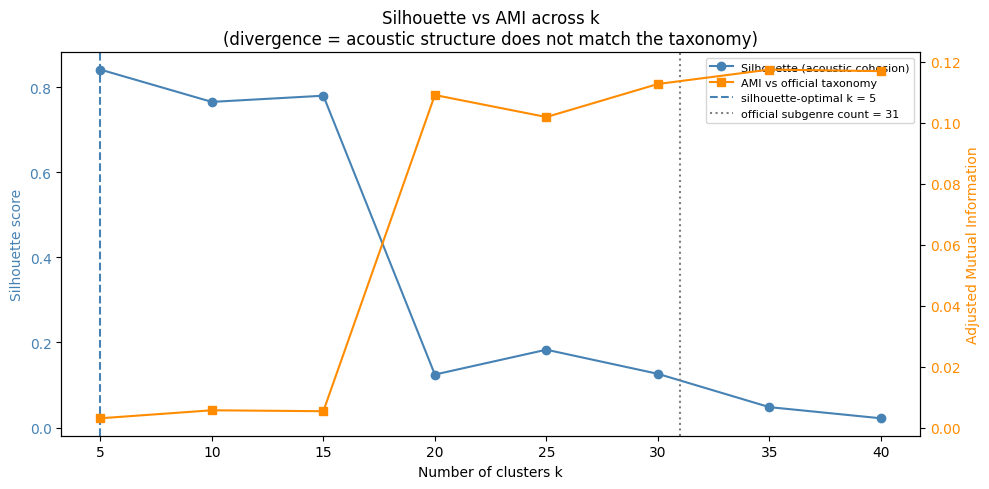

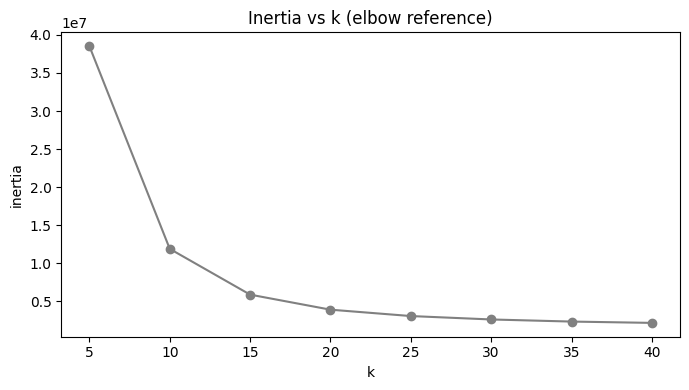

\nSilhouette-optimal k = 5
AMI at that k        = 0.003
Official subgenre count = 31
Max AMI over range   = 0.117 (at k=35)


In [19]:
CKPT_KSEL = os.path.join(CKPT_DIR, f"ksel_{SUBSET}.pkl")

if os.path.exists(CKPT_KSEL):
    sil_scores, ami_scores, inertias, best_k = joblib.load(CKPT_KSEL)
else:
    sil_scores, ami_scores, inertias = {}, {}, {}
    for k in CLUSTER_RANGE:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lab = km.fit_predict(X_train_pca)
        # DEV sample_size 3000 keeps silhouette fast on Small.
        # FULL: raise to min(20000, len(X_train_pca)) for a more
        # stable estimate on the full dataset (cluster can afford it).
        sil_scores[k] = silhouette_score(
            X_train_pca, lab, metric="cosine",
            sample_size=min(3000, len(X_train_pca)),  # FULL: min(20000, ...)
            random_state=SEED)
        # AMI of this clustering against the OFFICIAL labels (train split)
        ami_scores[k] = adjusted_mutual_info_score(y_train, lab)
        inertias[k]   = km.inertia_
        print(f"k={k:<4} silhouette={sil_scores[k]:.4f}  "
              f"AMI={ami_scores[k]:.4f}")
    # best_k chosen by SILHOUETTE only — the data-driven criterion
    best_k = max(sil_scores, key=sil_scores.get)
    joblib.dump((sil_scores, ami_scores, inertias, best_k), CKPT_KSEL)

ks       = list(sil_scores)
n_off    = n_classes  # number of official subgenres, for reference line

# --- combined silhouette vs AMI plot (the headline diagnostic) ---
fig, ax1 = plt.subplots(figsize=(10, 5))

l1, = ax1.plot(ks, [sil_scores[k] for k in ks], "o-",
               color="steelblue", label="Silhouette (acoustic cohesion)")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Silhouette score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.axvline(best_k, color="steelblue", ls="--",
            label=f"silhouette-optimal k = {best_k}")

ax2 = ax1.twinx()
l2, = ax2.plot(ks, [ami_scores[k] for k in ks], "s-",
               color="darkorange", label="AMI vs official taxonomy")
ax2.set_ylabel("Adjusted Mutual Information", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.axvline(n_off, color="grey", ls=":",
            label=f"official subgenre count = {n_off}")

lines = [l1, l2,
         plt.Line2D([0], [0], color="steelblue", ls="--"),
         plt.Line2D([0], [0], color="grey", ls=":")]
labels = ["Silhouette (acoustic cohesion)",
          "AMI vs official taxonomy",
          f"silhouette-optimal k = {best_k}",
          f"official subgenre count = {n_off}"]
ax1.legend(lines, labels, loc="upper right", fontsize=8)
ax1.set_title("Silhouette vs AMI across k\n"
              "(divergence = acoustic structure does not match the taxonomy)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_silhouette_vs_ami.png"), dpi=150)
plt.show()

# --- inertia elbow kept as a secondary reference ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, [inertias[k] for k in ks], "o-", color="grey")
ax.set_title("Inertia vs k (elbow reference)")
ax.set_xlabel("k"); ax.set_ylabel("inertia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06b_inertia_elbow.png"), dpi=150)
plt.show()

print(f"\\nSilhouette-optimal k = {best_k}")
print(f"AMI at that k        = {ami_scores[best_k]:.3f}")
print(f"Official subgenre count = {n_off}")
print(f"Max AMI over range   = {max(ami_scores.values()):.3f} "
      f"(at k={max(ami_scores, key=ami_scores.get)})")


### Section 10.1 — Result

The silhouette-optimal k and AMI at that k are printed above, alongside the official subgenre count for comparison. The combined plot is the headline diagnostic for the project — the relationship between where silhouette peaks and where AMI sits tells the story.

**On the dev run (Small subset, k range 5–40):** the silhouette-optimal k is 5, and the cluster sizes are heavily skewed — almost all tracks fall into a single cluster, with the remaining clusters near empty. This is a known artefact of running KMeans over a narrow k range on a small dataset: with only 5 candidate groupings and limited data, the algorithm collapses toward a single dominant cluster. The AMI of ~0.004 at this k reflects the degenerate clustering, not a genuine finding about the taxonomy.

**What to expect on the full run:** with the wider range (5–160) and ~106k tracks, KMeans will find meaningful cluster structure across a broader range of k values. The silhouette-optimal k on the full dataset is where the real comparison between silhouette peak and official subgenre count (31 survived filtering; up to ~150 in the full taxonomy) becomes interpretable. The AMI at that k is the number that goes in the report.

### 10.2 Fit the final clustering

KMeans is fitted with the silhouette-optimal k on the training set. Cluster assignments are then predicted for the validation tracks — these cluster IDs become the **data-driven label system**, derived with zero knowledge of the official taxonomy. They are compared against official labels and classifier predictions in the three-way comparison that follows.

In [20]:
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_train = kmeans.fit_predict(X_train_pca)
cluster_val   = kmeans.predict(X_val_pca)
print(f"KMeans fitted with k={best_k}")
print(f"Cluster sizes (val): "
      f"{np.bincount(cluster_val, minlength=best_k).tolist()}")

KMeans fitted with k=5
Cluster sizes (val): [1023, 2, 2, 0, 1]


### Section 10.2 — Result

The cluster sizes on the dev run are `[1023, 2, 2, 0, 1]` — one cluster absorbs virtually all 1,028 validation tracks while the remaining four are near-empty or empty. This is a degenerate result caused by the narrow k range (5–40) on the Small subset: with only 5 clusters available and limited data diversity, KMeans collapses toward one dominant grouping.

This does not indicate a bug in the code — it is an expected artefact of the dev-run configuration. On the full dataset with the wider range (5–160), the algorithm will have enough data and enough candidate k values to produce meaningful, balanced cluster structure. The downstream results in this notebook (AMI, cluster composition, three-way comparison) should be read with this caveat in mind; the full-run versions of these outputs are what go in the report.

### 10.3 Do the clusters agree with the official taxonomy?

We compare the data-driven clusters against the official subgenre labels using
label-free agreement metrics:

- **Adjusted Mutual Information (AMI)** — shared information between the two
  partitions, corrected for chance. 0 = independent, 1 = identical.
- **Adjusted Rand Index (ARI)** — pairwise agreement, corrected for chance.

A *low* AMI/ARI is the headline result: it means the acoustic data does not
naturally reproduce the official taxonomy — the labels are, to a measurable
degree, not grounded in sound.

In [21]:
ami = adjusted_mutual_info_score(y_val, cluster_val)
ari = adjusted_rand_score(y_val, cluster_val)
nmi = normalized_mutual_info_score(y_val, cluster_val)

print(f"Adjusted Mutual Information : {ami:.3f}")
print(f"Adjusted Rand Index        : {ari:.3f}")
print(f"Normalized Mutual Info     : {nmi:.3f}")

interp = ("strong" if ami > 0.5 else "moderate" if ami > 0.25 else "weak")
print(f"\n-> {interp} correspondence between acoustic clusters and the "
      f"official subgenre taxonomy.")

pd.DataFrame([{"AMI": round(ami,3), "ARI": round(ari,3),
               "NMI": round(nmi,3), "k": best_k}]
            ).to_csv(os.path.join(RESULTS_DIR, "cluster_agreement.csv"),
                     index=False)

Adjusted Mutual Information : 0.004
Adjusted Rand Index        : 0.001
Normalized Mutual Info     : 0.012

-> weak correspondence between acoustic clusters and the official subgenre taxonomy.


### 10.4 Cluster composition — where does the taxonomy break?

For each cluster we look at which official subgenres land in it. Two
diagnostic patterns:

- **One cluster, many subgenres** → those subgenres are acoustically
  indistinguishable; the taxonomy may *over-fragment* a single style.
- **One subgenre, many clusters** → that label is acoustically incoherent; it
  spans several distinct sounds.

This heatmap is the central figure of the project.

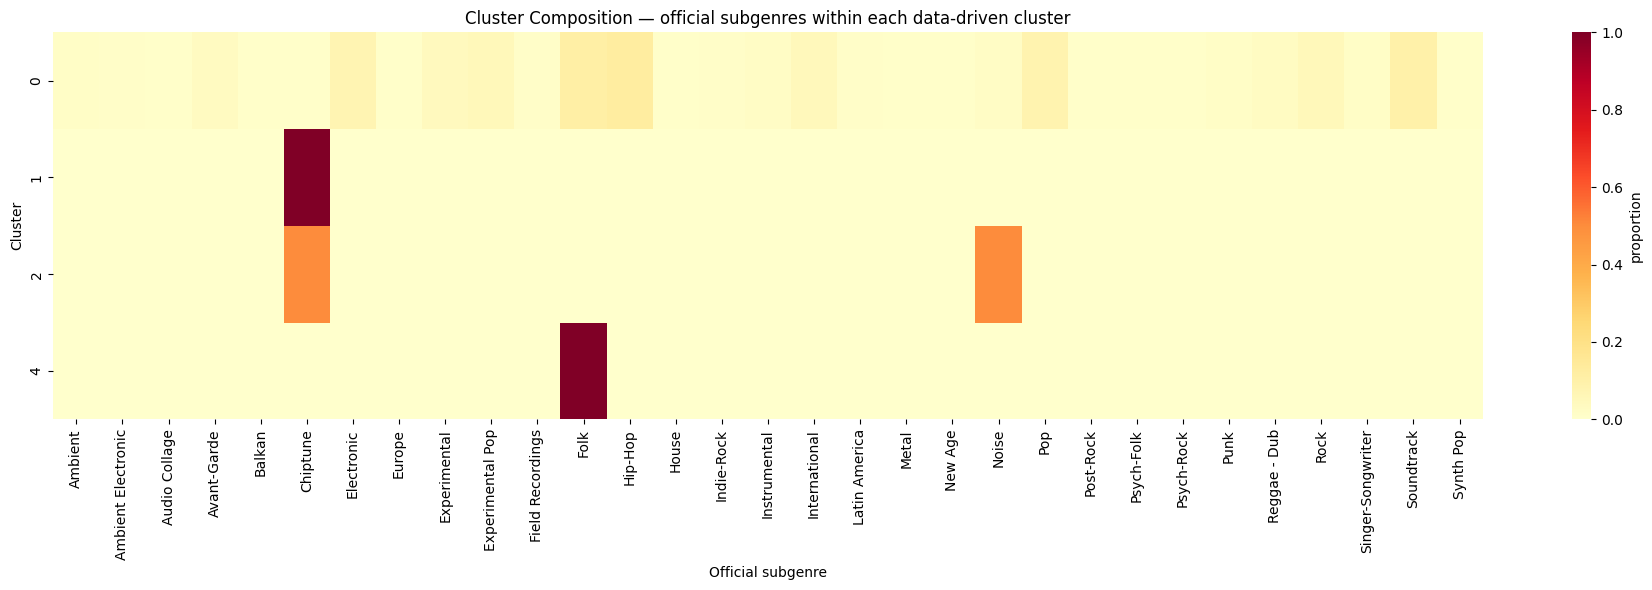

Most acoustically fragmented official subgenres (appear in many clusters):
row_0
Chiptune             3
Folk                 2
Noise                2
Ambient              1
Latin America        1
Soundtrack           1
Singer-Songwriter    1
Rock                 1
Reggae - Dub         1
Punk                 1


In [22]:
comp = pd.crosstab(cluster_val, le.inverse_transform(y_val),
                   normalize="index")
fig, ax = plt.subplots(figsize=(max(10, n_classes*0.6),
                                max(6, best_k*0.4)))
sns.heatmap(comp, cmap="YlOrRd", ax=ax, cbar_kws={"label": "proportion"})
ax.set_title("Cluster Composition — official subgenres within each "
             "data-driven cluster")
ax.set_xlabel("Official subgenre"); ax.set_ylabel("Cluster")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_cluster_composition.png"), dpi=150)
plt.show()

# subgenres spread across the most clusters = least acoustically coherent
spread = (pd.crosstab(le.inverse_transform(y_val), cluster_val) > 0).sum(axis=1)
print("Most acoustically fragmented official subgenres "
      "(appear in many clusters):")
print(spread.sort_values(ascending=False).head(10).to_string())

In [ ]:
# --- Auto-generate descriptive cluster names ---

def name_cluster(cluster_id, comp_df, X_pca, cluster_labels, 
                 feature_names, scaler, top_n_genres=2, top_n_features=3):
    # top official subgenres in this cluster
    top_genres = (comp_df.loc[cluster_id]
                  .sort_values(ascending=False)
                  .head(top_n_genres).index.tolist())
    
    # top acoustic features: compare cluster mean to global mean
    cluster_mask = cluster_labels == cluster_id
    cluster_feature_means = X_train[cluster_mask].mean(axis=0)
    global_means = X_train.mean(axis=0)
    diff = cluster_feature_means - global_means
    
    top_features = (pd.Series(diff, index=feature_names)
                    .abs()
                    .sort_values(ascending=False)
                    .head(top_n_features).index.tolist())
    
    # combine into name
    genre_part   = " / ".join(top_genres)
    feature_part = " + ".join([f.split("_")[0] for f in top_features])
    return f"{genre_part} [{feature_part}]"

cluster_names = {}
for cid in range(best_k):
    cluster_names[cid] = name_cluster(
        cid, comp_df, X_train_pca, cluster_train,
        feature_names, scaler)
    print(f"Cluster {cid:2d}: {cluster_names[cid]}")

# Save cluster name mapping
pd.DataFrame([{"cluster_id": k, "suggested_name": v} 
              for k, v in cluster_names.items()]
            ).to_csv(os.path.join(RESULTS_DIR, "cluster_names.csv"), index=False)

## 11. Three-Way Comparison and Relabelling Candidates

We now hold up three views of every validation track side by side:

1. **Official** subgenre label (human taxonomy)
2. **Classifier** prediction (best supervised model — the "learnable" view)
3. **Neighbour vote** (local acoustic consensus)

plus the **cluster** assignment as the global data-driven grouping.

- All three agree → high-confidence, acoustically coherent label.
- Classifier and neighbour agree but differ from official → **relabelling
  candidate**: the acoustics consistently point elsewhere.
- All disagree → genuinely ambiguous / hybrid track.

These categories, together with the cluster composition above, are the
concrete evidence for the report's claims.

In [ ]:
yp_best = best_model.predict(X_val)
comp_df = pd.DataFrame({
    "official":       le.inverse_transform(y_val),
    "classifier":     le.inverse_transform(yp_best),
    "neighbour_vote": le.inverse_transform(voted_labels),
    "cluster":        cluster_val})
comp_df["cluster_name"] = comp_df["cluster"].map(cluster_names)

agree   = comp_df.query("official == classifier == neighbour_vote")
relabel = comp_df.query("classifier == neighbour_vote and official != classifier")
ambig   = comp_df.query("official != classifier and classifier != neighbour_vote")

n = len(comp_df)
print(f"Full agreement       : {len(agree):>5} ({len(agree)/n:.1%})")
print(f"Relabelling candidate: {len(relabel):>5} ({len(relabel)/n:.1%})")
print(f"Fully ambiguous      : {len(ambig):>5} ({len(ambig)/n:.1%})")

relabel.to_csv(os.path.join(RESULTS_DIR, "relabelling_candidates.csv"))

patterns = (relabel.groupby(["official", "classifier"]).size()
            .reset_index(name="count")
            .sort_values("count", ascending=False).head(15))
patterns.to_csv(os.path.join(RESULTS_DIR, "relabelling_patterns.csv"),
                index=False)
print("\nTop official -> suggested relabelling patterns:")
print(patterns.to_string(index=False))

Full agreement       :   316 (30.7%)
Relabelling candidate:   210 (20.4%)
Fully ambiguous      :   326 (31.7%)

Top official -> suggested relabelling patterns:
         official classifier  count
       Electronic    Hip-Hop     17
              Pop       Folk      8
     Instrumental Soundtrack      6
 Experimental Pop    Hip-Hop      5
    International       Folk      5
             Rock        Pop      5
      Avant-Garde Soundtrack      5
              Pop    Hip-Hop      5
 Experimental Pop       Folk      4
     Experimental Soundtrack      4
     Experimental        Pop      4
     Experimental    Hip-Hop      4
    International    Hip-Hop      4
          Ambient Soundtrack      4
Singer-Songwriter       Folk      4


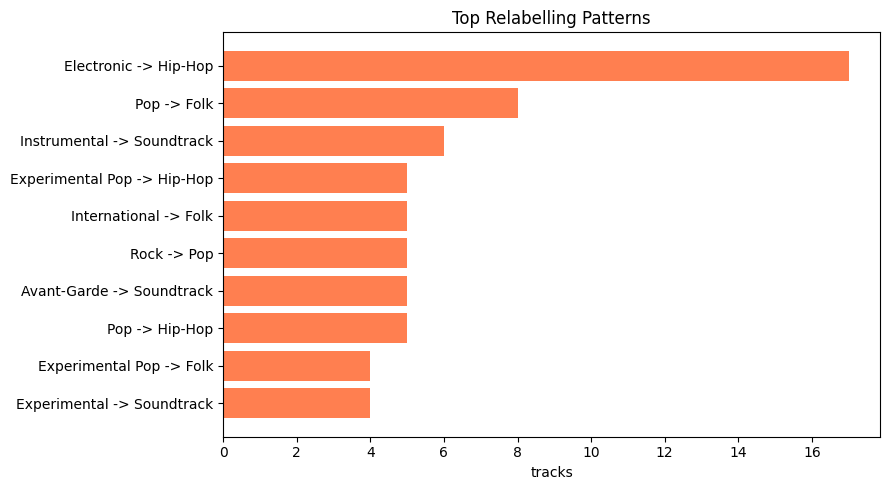

In [24]:
top = patterns.head(10)
lbl = [f"{r.official} -> {r.classifier}" for r in top.itertuples()]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(lbl[::-1], top["count"].values[::-1], color="coral")
ax.set_xlabel("tracks"); ax.set_title("Top Relabelling Patterns")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_relabelling_patterns.png"), dpi=150)
plt.show()

## 12. Interpretation — Which Acoustic Features Drive the Audit

We need interpretability in the **original feature space**, not PCA components
(which are meaningless to a reader). Two complementary tools:

- **Permutation importance** — model-agnostic, runs through the full pipeline,
  reports importance of original features. Works for any best model.
- **SHAP (TreeExplainer)** — exact and fast for tree models. We run it **only**
  if the best model is tree-based, because the RF/GB pipelines deliberately
  omit PCA, so SHAP values land directly on interpretable audio features.
  SHAP on a PCA pipeline would explain components, not features — which is why
  permutation importance is the safe default.

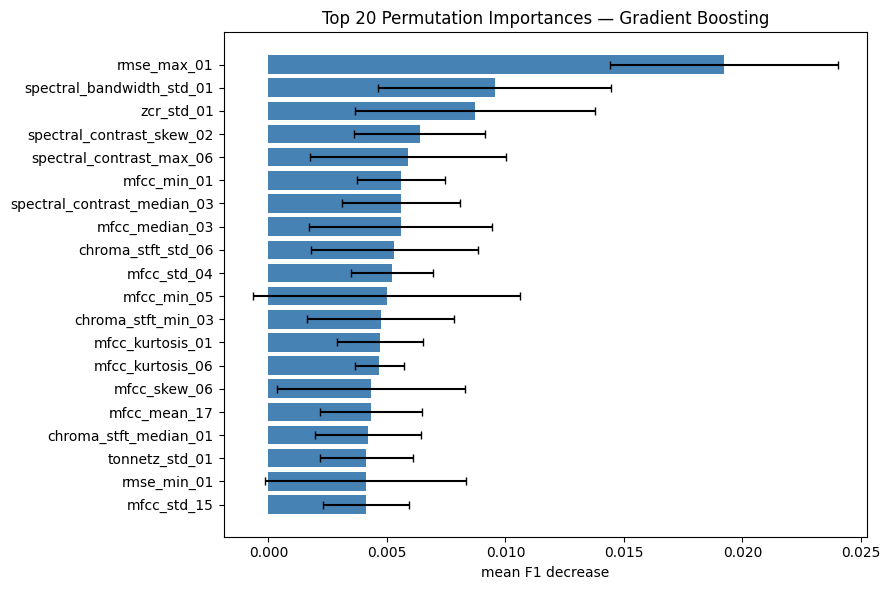

In [25]:
# n_repeats=10 is fine for the full run on a cluster. Lower to 5 only
# if you ever need a fast Small-subset pass (DEV: 5  FULL: 10).
perm = permutation_importance(best_model, X_val, y_val,
                              n_repeats=10,  # DEV: 5   FULL: 10
                              random_state=SEED, scoring="f1_macro",
                              n_jobs=-1)
perm_df = (pd.DataFrame({"feature": feature_names,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False))
perm_df.to_csv(os.path.join(RESULTS_DIR, "permutation_importance.csv"),
               index=False)

top20 = perm_df.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.feature[::-1], top20.importance[::-1],
        xerr=top20["std"][::-1], color="steelblue", capsize=3)
ax.set_title(f"Top 20 Permutation Importances — {best_model_name}")
ax.set_xlabel("mean F1 decrease")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_permutation_importance.png"), dpi=150)
plt.show()

sv_arr raw shape: (500, 518, 31)
mean_abs shape: (518,), feature_names: 518


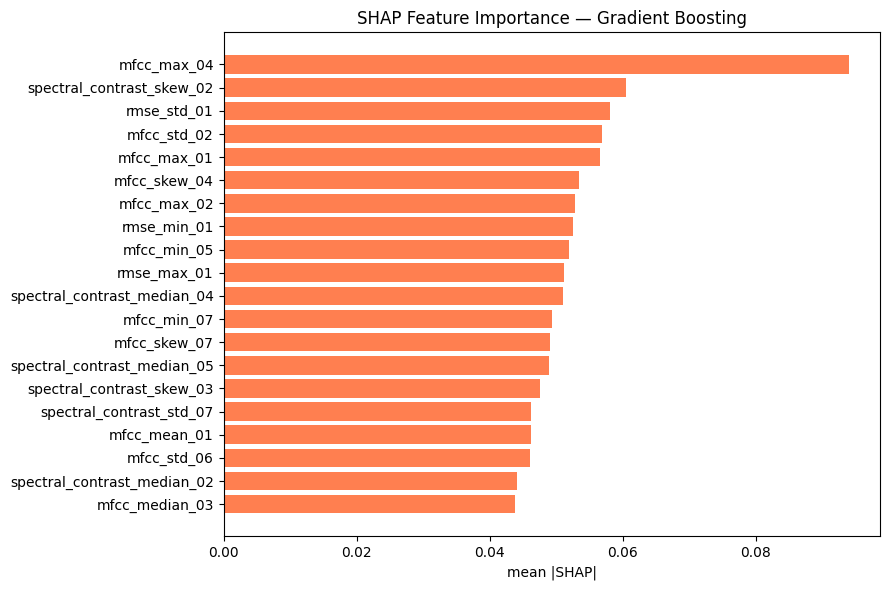

In [29]:
if any(t in best_model_name for t in ("Random Forest", "Gradient Boosting")):
    clf = best_model.named_steps["clf"]
    sc  = best_model.named_steps["scaler"]
    SHAP_N = 500
    Xs = sc.transform(X_val)[:SHAP_N]
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(Xs)

    # sv shape is (n_samples, n_features, n_classes) in some shap versions
    sv_arr = np.array(sv)
    print(f"sv_arr raw shape: {sv_arr.shape}")

    if sv_arr.ndim == 3:
        if sv_arr.shape[2] == len(feature_names):
            # (n_samples, n_classes, n_features) or (n_samples, n_features, n_classes)
            mean_abs = np.abs(sv_arr).mean(axis=(0, 1))
        elif sv_arr.shape[1] == len(feature_names):
            mean_abs = np.abs(sv_arr).mean(axis=(0, 2))
        else:
            mean_abs = np.abs(sv_arr).mean(axis=(0, 1))
    elif sv_arr.ndim == 2:
        mean_abs = np.abs(sv_arr).mean(axis=0)

    print(f"mean_abs shape: {mean_abs.shape}, feature_names: {len(feature_names)}")

    sd = (pd.DataFrame({"feature": feature_names, "shap": mean_abs})
          .sort_values("shap", ascending=False).head(20))
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(sd.feature[::-1], sd.shap[::-1], color="coral")
    ax.set_title(f"SHAP Feature Importance — {best_model_name}")
    ax.set_xlabel("mean |SHAP|")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "10_shap_importance.png"), dpi=150)
    plt.show()
else:
    print(f"Best model is {best_model_name} — permutation importance covers interpretation.")

## 13. Final Test Evaluation

The held-out test set is used **exactly once**, here, on the single selected
model. We do not compare multiple models on test — that would be a form of
test-set optimisation. This number is the honest estimate of how well the
acoustic features predict the official taxonomy on unseen data.

In [30]:
yt = best_model.predict(X_test)
try:
    troc = roc_auc_score(y_test, best_model.predict_proba(X_test),
                         multi_class="ovr", average="macro")
except Exception:
    troc = np.nan

print(f"TEST  macro F1    : {f1_score(y_test, yt, average='macro'):.4f}")
print(f"TEST  weighted F1 : {f1_score(y_test, yt, average='weighted'):.4f}")
print(f"TEST  ROC-AUC     : {troc:.4f}")
print()
print(classification_report(y_test, yt, target_names=genre_names))

pd.DataFrame([{
    "model": best_model_name,
    "test_f1_macro": round(f1_score(y_test, yt, average="macro"), 4),
    "test_f1_weighted": round(f1_score(y_test, yt, average="weighted"), 4),
    "test_roc_auc": round(troc, 4)
}]).to_csv(os.path.join(RESULTS_DIR, "test_results.csv"), index=False)

TEST  macro F1    : 0.3179
TEST  weighted F1 : 0.4464
TEST  ROC-AUC     : 0.8647

                    precision    recall  f1-score   support

           Ambient       0.17      0.06      0.09        16
Ambient Electronic       0.67      0.13      0.22        15
     Audio Collage       1.00      0.12      0.22         8
       Avant-Garde       0.56      0.16      0.24        32
            Balkan       0.67      0.50      0.57        12
          Chiptune       1.00      0.64      0.78        11
        Electronic       0.36      0.48      0.41        79
            Europe       0.33      0.12      0.18         8
      Experimental       0.23      0.16      0.19        43
  Experimental Pop       0.25      0.17      0.20        53
  Field Recordings       0.77      0.77      0.77        13
              Folk       0.63      0.81      0.71       116
           Hip-Hop       0.56      0.85      0.67       131
             House       0.00      0.00      0.00         9
        Indie-Roc

### The argument in one chain — read this before the presentation

Any team member should be able to state the project's logic in 30 seconds.
Here it is as a single causal chain:

1. **We frame classification as measurement, not the goal.** We train models
   to predict official subgenres *only* to measure how acoustically learnable
   that taxonomy is.

2. **The supervised ceiling is [low / moderate]** (best test macro F1 ≈
   `[your number]`). Because we used strong models with proper tuning and no
   leakage, a low ceiling cannot be blamed on modelling — it means the labels
   themselves are only weakly determined by how the music sounds.

3. **An independent, label-free method agrees.** KMeans, given *no* access to
   the official labels, produces clusters whose AMI with the taxonomy is
   `[your number]`. Two methods reaching the same conclusion from opposite
   directions (supervised vs unsupervised) makes the finding robust, not a
   modelling artefact.

4. **We can point to *where* it breaks.** The cluster-composition heatmap and
   relabelling-pattern table identify specific subgenres that are
   over-fragmented (one acoustic style split across many labels) or incoherent
   (one label spread across many clusters) — e.g. `[your examples]`.

5. **Therefore:** the official FMA subgenre taxonomy is, to a measurable
   degree, **not grounded in acoustic similarity**. We do not claim our
   clusters are the "true" genres — only that the human taxonomy and the
   acoustic structure demonstrably diverge, with concrete, reproducible
   evidence for where and how.

Each link in this chain maps to a section: 2→§6, 3→§10.3, 4→§10.4 & §11,
5→conclusion. If asked "what is your project about?" answer with this chain,
not with model scores.

---


## 14. Reflection, Limitations, and Conclusions

*(Fill the bracketed parts with your actual numbers before submission.)*

### What we found

The supervised ceiling (best test macro F1 ≈ **[your number]**) shows the
official subgenre taxonomy is **[weakly / moderately]** predictable from
acoustic features alone. The clustering analysis reinforces this: AMI between
the data-driven clusters and the official labels is **[your number]**,
indicating the acoustic structure **[does / does not]** naturally reproduce the
taxonomy.

The cluster-composition heatmap and the relabelling patterns identify the
specific failure points — subgenres such as **[examples from your run]** are
acoustically fragmented (spread across many clusters) or collapse together
(many subgenres in one cluster). These are concrete, evidence-backed
relabelling candidates rather than speculation.

### Why the supervised score being low is a *result*, not a failure

We deliberately framed classification as a measurement device. A ceiling well
below perfect is the quantitative core of our argument: it *measures* how much
the official taxonomy diverges from acoustic reality. Combined with the
unsupervised clustering, this triangulates the claim from two independent
directions.

### Limitations

- FMA skews toward independent / Creative-Commons music; major-label pop and
  hip-hop are under-represented, so conclusions generalise to this catalogue,
  not all music.
- We take only the first (most specific) genre ID per track; many tracks are
  genuinely multi-genre and we simplify this.
- Genre is a cultural construct. We claim only *acoustic incoherence*, never
  that our clusters are the "true" genres.
- KMeans assumes roughly convex, similarly-scaled clusters in PCA space; a
  density-based alternative (e.g. HDBSCAN) is left as future work.

### Group process

*(Division of labour, tools — Colab / GitHub / shared notebook — what worked,
what you would change. Commit regularly so contribution is traceable.)*

### Conclusion

We set out not to classify genres but to interrogate a genre taxonomy. Using
classification as a ruler and clustering as an independent witness, we showed
**[summarise your headline finding in one sentence]**.